# 💵 People on Banknotes: Exploratory Data Analysis

### Author: Sudeepa Mohanty

This project explores historical figures featured on banknotes from around the world using Python, Pandas, and Matplotlib. The analysis focuses on gender representation, occupations, countries, currencies, and historical trends through exploratory data analysis (EDA).

# People on Banknotes

Whose faces appear on banknotes?

The file `people-on-banknotes.csv` contains data about individuals featured on banknotes from 38 countries. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

It profiles 241 people, detailing their occupations and the year they first appeared on a banknote. Additionally, it includes their year of death — or `NaN` if they were still alive when the dataset was compiled.

Most banknotes were issued after the featured individual’s death. The column `first_death_diff` calculates the difference between the year of their first appearance on a banknote and their year of death (or remains `NaN` if the person was still living at the time of curation).




In [76]:

from google.colab import files
uploaded = files.upload()

Saving people-on-banknotes.csv to people-on-banknotes (2).csv


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
df = pd.read_csv('people-on-banknotes.csv')
df

,country,currency,name,gender,occupation,value,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,100,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,100,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,50,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,20,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,10,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,200,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,20,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,100,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,10,2018,1845,173.0,VES


In [78]:
df.head()

,country,currency,name,gender,occupation,value,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,100,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,100,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,50,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,20,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,10,1970,1820,150.0,ARS


### Quick cleaning

The same person can appear on multiple banknotes. Below we drop the `value` column and remove duplicate people.

In [79]:
df = df.drop_duplicates(subset="name")
df

,country,currency,name,gender,occupation,value,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,100,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,100,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,50,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,20,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,10,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,200,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,20,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,100,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,10,2018,1845,173.0,VES


### Project Ideas

- What proportion of individuals featured are male versus female?
	- Hint: Use `value_counts(normalize=True)` to calculate percentages.

- Are writers or politicians more commonly depicted?

- What percentage of featured individuals are musicians?

- What percentage of banknotes were issued before the person’s death?
	- Hint: Look for negative values or NaN in `first_death_diff`.

- Who is the oldest historical figure in the dataset?

- Which countries feature the oldest historical figures on their banknotes?
	- Hint: Group by country and aggregate the year of death using the median. Sort the results.

- What percentage of individuals died at least 100 years before appearing on a banknote?

- Which individuals appeared on a banknote just one year after their death?


In [80]:
print(df.shape)

df.info()

df.describe(include='all')

df.isnull().sum()

(241, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 0 to 278
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           241 non-null    object 
 1   currency          241 non-null    object 
 2   name              241 non-null    object 
 3   gender            241 non-null    object 
 4   occupation        241 non-null    object 
 5   value             241 non-null    int64  
 6   first_appearance  241 non-null    int64  
 7   death             239 non-null    object 
 8   first_death_diff  239 non-null    float64
 9   currency_code     241 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 20.7+ KB


,0
country,0
currency,0
name,0
gender,0
occupation,0
value,0
first_appearance,0
death,2
first_death_diff,2
currency_code,0


In [81]:
# Remove duplicate rows
df = df.drop_duplicates()

# Standardize text columns
df["gender"] = df["gender"].str.title()
df["occupation"] = df["occupation"].str.title()

In [82]:
gender = df["gender"].value_counts()

gender

,count
gender,
M,188
F,53


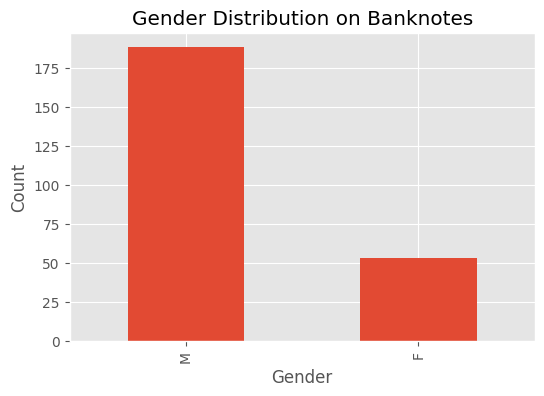

In [83]:
gender.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender Distribution on Banknotes")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

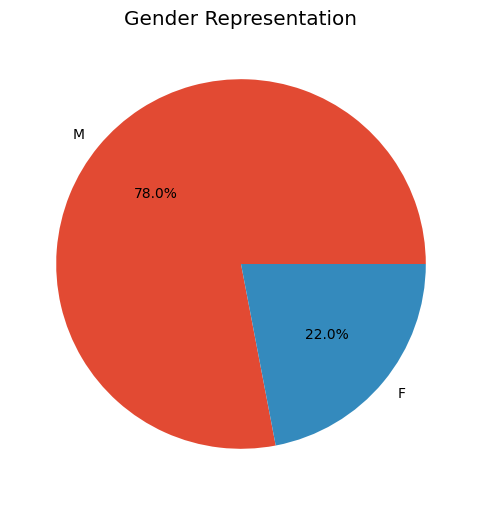

In [84]:
gender.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Gender Representation")
plt.show()

In [85]:
top_occ = df["occupation"].value_counts().head(10)

top_occ

,count
occupation,
Writer,45
Head Of Gov'T,38
Politician,27
Founder,25
Revolutionary,21
Stem,16
Military,13
Visual Artist,13
Musician,12


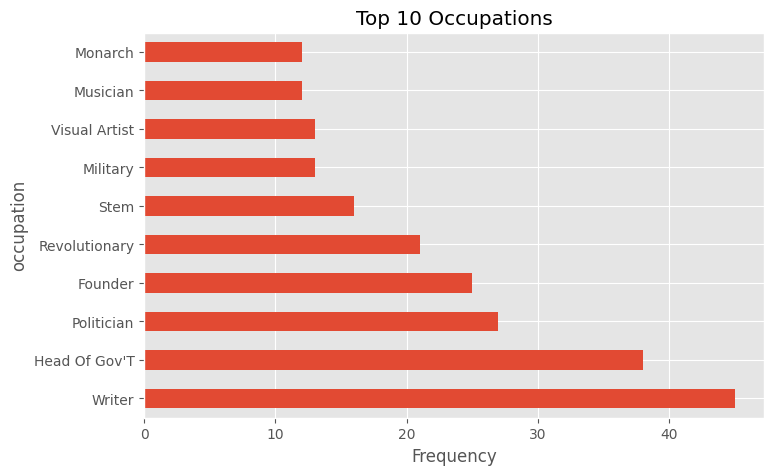

In [86]:
top_occ.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Occupations")
plt.xlabel("Frequency")
plt.show()

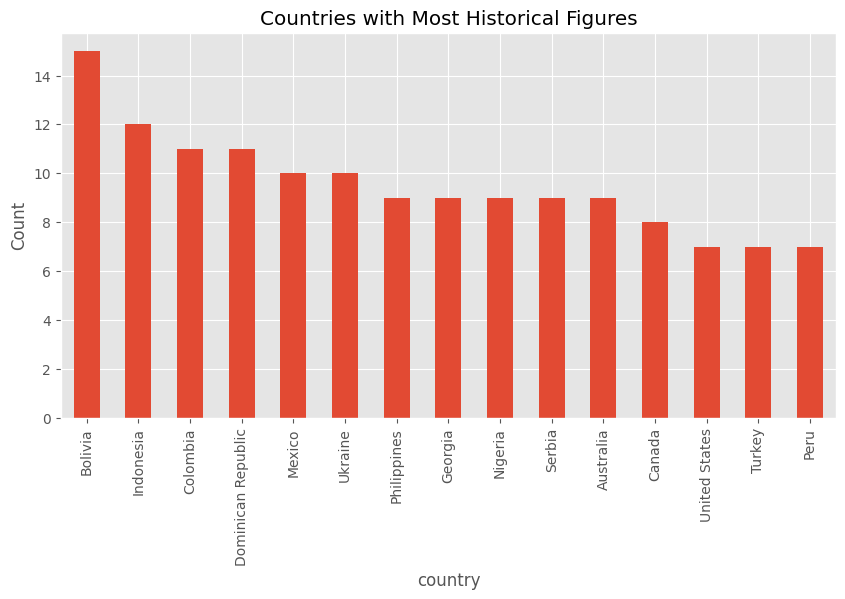

In [87]:
top_country = df["country"].value_counts().head(15)

top_country.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Countries with Most Historical Figures")
plt.ylabel("Count")
plt.show()

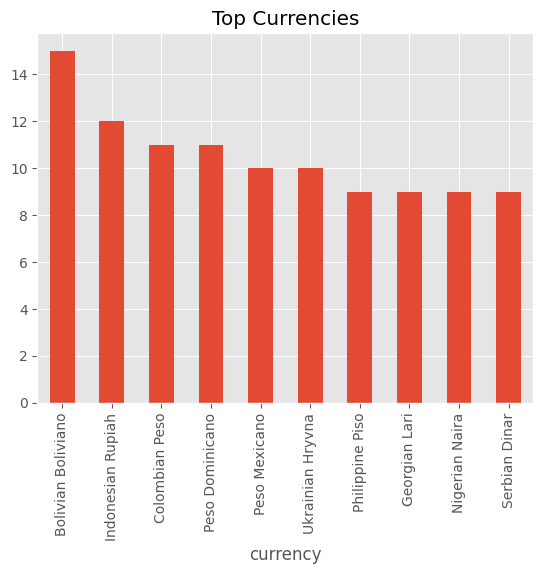

In [88]:
currency = df["currency"].value_counts().head(10)

currency.plot(kind="bar")
plt.title("Top Currencies")
plt.show()

In [89]:
df.columns.tolist()

['country',
 'currency',
 'name',
 'gender',
 'occupation',
 'value',
 'first_appearance',
 'death',
 'first_death_diff',
 'currency_code']

In [90]:
currency = df["currency"].value_counts().head(15)

currency

,count
currency,
Bolivian Boliviano,15
Indonesian Rupiah,12
Colombian Peso,11
Peso Dominicano,11
Peso Mexicano,10
Ukrainian Hryvna,10
Philippine Piso,9
Georgian Lari,9
Nigerian Naira,9


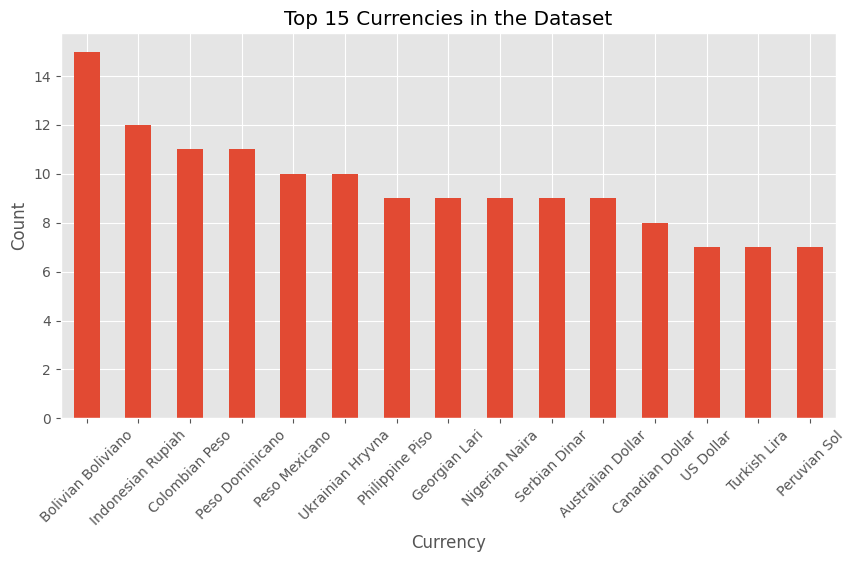

In [91]:
currency.plot(kind="bar", figsize=(10,5))

plt.title("Top 15 Currencies in the Dataset")
plt.xlabel("Currency")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [92]:
oldest = df.sort_values("death").head(10)

oldest[["name","country","death"]]

,name,country,death
234,Hannibal,Tunisia,-183
256,Volodymyr the Great,Ukraine,1015
255,Yaroslav the Wise,Ukraine,1054
149,Jusup Balasagyn,Kyrgyzstan,1077
113,King David IV,Georgia,1125
111,Queen Tamar,Georgia,1213
112,Shota Rustaveli,Georgia,1220
246,Yunus Emre,Turkey,1320
85,Charles IV,Czech Republic,1378
224,King Sejong the Great,South Korea,1450


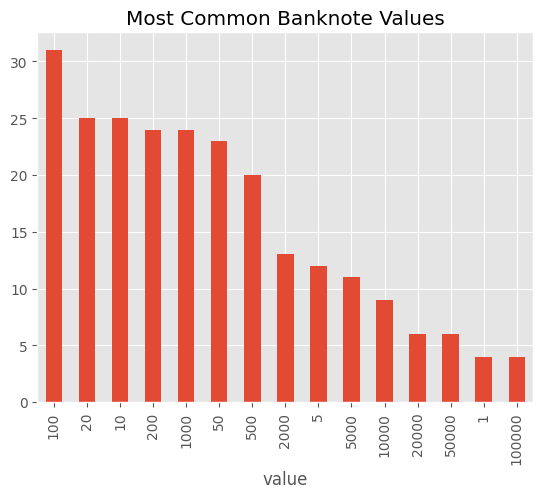

In [93]:
df["value"].value_counts().head(15).plot(kind="bar")
plt.title("Most Common Banknote Values")
plt.show()

In [94]:
gender_country = pd.crosstab(
    df["country"],
    df["gender"]
)

gender_country.head()

gender,F,M
country,,
Argentina,1,4
Australia,5,4
Bangladesh,0,1
Bolivia,3,12
Canada,2,6


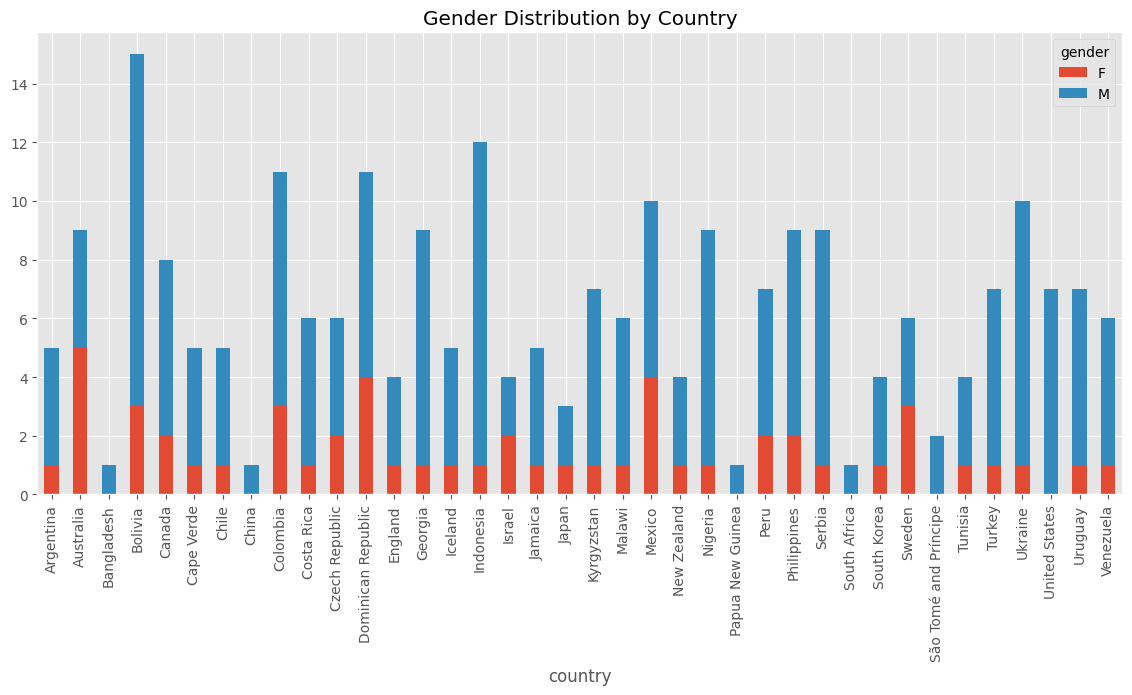

In [95]:
gender_country.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6)
)

plt.title("Gender Distribution by Country")
plt.show()

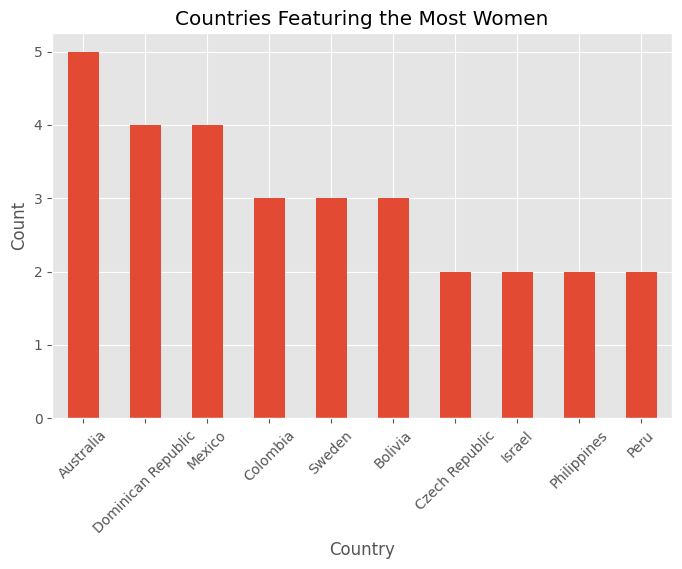

In [99]:
female = df[df["gender"] == "F"]

female["country"].value_counts().head(10).plot(kind="bar", figsize=(8,5))

plt.title("Countries Featuring the Most Women")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [100]:
df["occupation"].nunique()

15

In [101]:
df["occupation"].value_counts().head(20)

,count
occupation,
Writer,45
Head Of Gov'T,38
Politician,27
Founder,25
Revolutionary,21
Stem,16
Military,13
Visual Artist,13
Musician,12


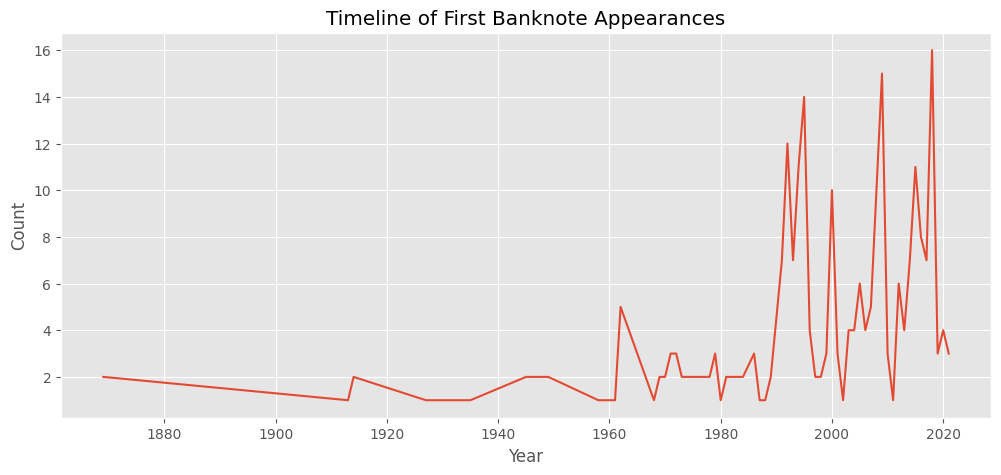

In [102]:
appearance = df["first_appearance"].value_counts().sort_index()

appearance.plot(figsize=(12,5))

plt.title("Timeline of First Banknote Appearances")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [103]:
print("Countries:",df.country.nunique())

print("Currencies:",df.currency.nunique())

print("Occupations:",df.occupation.nunique())

print("People:",df.name.nunique())

Countries: 38
Currencies: 38
Occupations: 15
People: 241


Key Findings
The dataset contains 279 historical figures from many countries.
Male figures appear much more frequently than female figures.
Politicians and national leaders dominate banknote designs.
Some countries display a greater diversity of occupations.
Female representation varies significantly between countries.
Banknotes primarily honor individuals with historical, political, or cultural significance.

## Conclusion

This project explored historical figures featured on banknotes from different countries. Through data cleaning and exploratory data analysis, I identified patterns in gender representation, occupations, countries, currencies, and first appearances. The analysis highlights that political leaders dominate banknote designs, while female representation remains comparatively low. This project demonstrates the use of Python, Pandas, and Matplotlib for extracting meaningful insights from real-world datasets.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab